In [2]:
import wandb
import transformers
import torch
import pandas as pd
import os, glob, re, random
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.decomposition import PCA
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm
import os, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math
from pathlib import Path

In [3]:
import os
import sys
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

sapiens_dir = "../../Sapiens-Pytorch-Inference"

if not os.path.isdir(sapiens_dir):
    raise FileNotFoundError(f"Sapiens-Ordner nicht gefunden: {sapiens_dir}")

sys.path.insert(0, sapiens_dir)

from sapiens_inference import (
    SapiensDepth,
    SapiensDepthType,
    SapiensSegmentation,
    SapiensSegmentationType,
    SapiensConfig,
)

config = SapiensConfig()
config.depth_type = SapiensDepthType.DEPTH_1B
config.segmentation_type = SapiensSegmentationType.SEGMENTATION_1B

if torch.cuda.is_available():
    config.device = "cuda"
else:
    print("cpu")
    config.device = "cpu"

orig_cwd = os.getcwd()
try:
    os.makedirs(os.path.join(sapiens_dir, "models"), exist_ok=True)
    os.chdir(sapiens_dir)
    depth_predictor = SapiensDepth(config.depth_type, config.device, config.dtype)
    seg_predictor = SapiensSegmentation(config.segmentation_type, config.device, config.dtype)
finally:
    os.chdir(orig_cwd)

print("device", config.device)


def run_sapiens_on_image(img_path):
    pil = Image.open(img_path).convert("RGB")
    rgb_np = np.array(pil)
    bgr_np = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2BGR)
    H, W = bgr_np.shape[:2]

    # Segmentation
    seg_logits = seg_predictor(bgr_np)
    if isinstance(seg_logits, torch.Tensor):
        seg_map = seg_logits.squeeze().cpu().numpy()
    else:
        seg_map = seg_logits

    if seg_map.shape != (H, W):
        seg_map = cv2.resize(seg_map, (W, H), interpolation=cv2.INTER_LINEAR)

    human_mask = (seg_map > 0.5).astype(np.uint8)

    return rgb_np, human_mask

cpu
device cpu


In [4]:
def run_sapiens_depth_with_bg_far(img_path):
    pil = Image.open(img_path).convert("RGB")
    rgb_np = np.array(pil)
    bgr_np = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2BGR)
    H, W = bgr_np.shape[:2]

    # --- 1) Segmentation für human_mask (sonst kannst du bg nicht setzen)
    seg_logits = seg_predictor(bgr_np)
    if isinstance(seg_logits, torch.Tensor):
        seg_map = seg_logits.squeeze().detach().cpu().numpy()
    else:
        seg_map = np.squeeze(seg_logits)

    if seg_map.shape != (H, W):
        seg_map = cv2.resize(seg_map, (W, H), interpolation=cv2.INTER_LINEAR)

    human_mask = (seg_map > 0.5).astype(np.uint8)

    # --- 2) Depth
    depth_raw = depth_predictor(bgr_np)
    if isinstance(depth_raw, torch.Tensor):
        depth_np = depth_raw.squeeze().detach().cpu().numpy()
    else:
        depth_np = np.squeeze(depth_raw)

    if depth_np.shape != (H, W):
        depth_np = cv2.resize(depth_np, (W, H), interpolation=cv2.INTER_LINEAR)

    # --- 3) Normalisieren (robust gegen NaNs / konstante Maps)
    d_min, d_max = np.nanmin(depth_np), np.nanmax(depth_np)
    depth_norm = (depth_np - d_min) / (d_max - d_min + 1e-8)
    depth_norm = np.clip(depth_norm, 0.0, 1.0)

    # OPTIONAL: falls die Tiefe "falsch herum" ist (nah=hell statt dunkel etc.)
    # depth_norm = 1.0 - depth_norm

    # --- 4) Hintergrund auf "weit weg" setzen
    modified_depth = np.where(human_mask == 1, depth_norm, 1.0)

    # --- 5) Visualisierung
    modified_8u = (modified_depth * 255).astype(np.uint8)
    depth_color_bgr = cv2.applyColorMap(modified_8u, cv2.COLORMAP_TURBO)
    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)

    return rgb_np, human_mask, depth_norm, depth_color_rgb, depth_raw


In [5]:
img_path = "../../data/media_images_qwen_input_image_56_795a65b9487aaf2e6ffd.png"

rgb, human_mask, depth_norm, depth_color_rgb, depth_raw = run_sapiens_depth_with_bg_far(img_path)


Segmentation inference took: 181.5403 seconds
Depth inference took: 158.5399 seconds


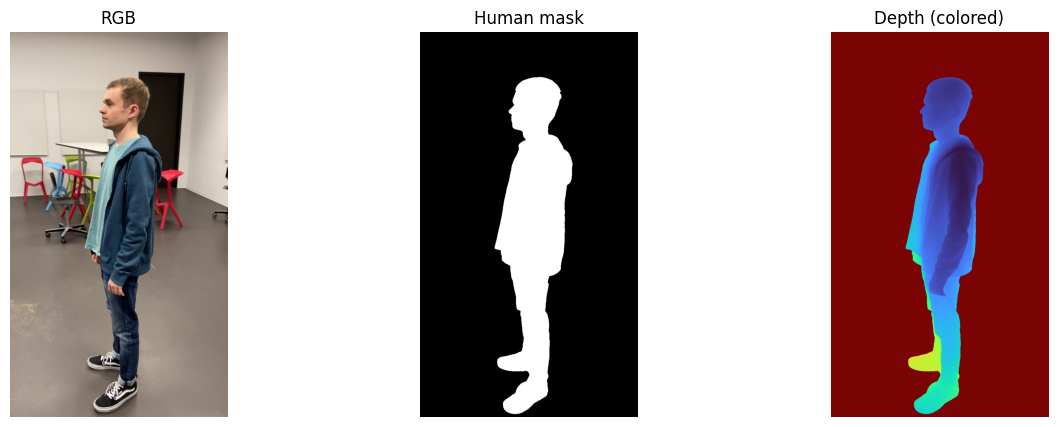

In [6]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("RGB")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Human mask")
plt.imshow(human_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Depth (colored)")
plt.imshow(depth_color_rgb)
plt.axis("off")

plt.show()

In [12]:
#plot real iamgs with dpthmaps overlaid
def plot_rgb_with_depth_overlay(rgb, depth_norm, alpha=0.5):
    depth_color_bgr = cv2.applyColorMap((depth_norm * 255).astype(np.uint8), cv2.COLORMAP_TURBO)
    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(rgb, 1 - alpha, depth_color_rgb, alpha, 0)
    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("RGB with Depth Overlay")
    plt.show()

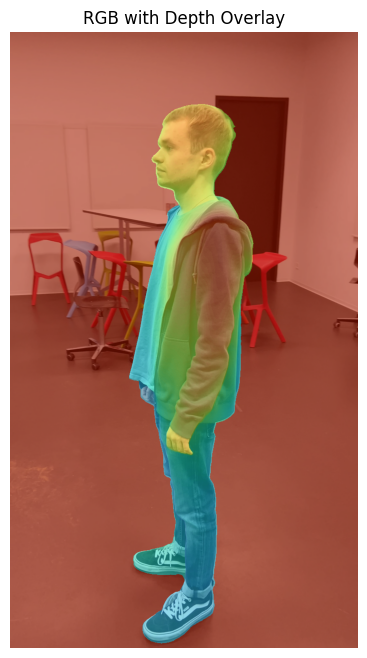

In [13]:
plot_rgb_with_depth_overlay(rgb, depth_color_rgb, alpha=0.5)

# Experiment Analysis

In [23]:
def plot_wandb_images_triplet_by_index(
        run,
        metrics,
        *,
        title: str = "",
        labels=None,
        step_key: str = "_step",
        samples: int = 5000,
        max_rows: int = 9,
        start: int = 0,
        unique: bool = True,
        download_dir: str = "./wandb_media_cache",
        figsize_per_cell=(4.0, 4.0),
        show_step: bool = False,
        strict_equal_lengths: bool = False,
):
    if not isinstance(metrics, (list, tuple)) or len(metrics) != 3:
        raise ValueError("metrics must be a list/tuple with exactly 3 entries.")
    if labels is None:
        labels = list(metrics)
    if not isinstance(labels, (list, tuple)) or len(labels) != 3:
        raise ValueError("labels must be None or a list/tuple with exactly 3 entries.")

    df = run.history(samples=samples)
    if df is None or df.empty:
        raise ValueError("run.history() is empty.")

    missing = [c for c in metrics if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in history: {missing}")

    cache_root = Path(download_dir)
    cache_root.mkdir(parents=True, exist_ok=True)

    def _extract_path_or_url(obj):
        if isinstance(obj, dict):
            return obj.get("path"), obj.get("url")
        if hasattr(obj, "path"):
            return getattr(obj, "path"), None
        if hasattr(obj, "_path"):
            return getattr(obj, "_path"), None
        if isinstance(obj, str):
            if obj.startswith("http"):
                return None, obj
            return obj, None
        return None, None

    def _load_image(obj):
        if hasattr(obj, "image") and obj.image is not None:
            return np.array(obj.image)

        path, url = _extract_path_or_url(obj)

        if url:
            raise ValueError(
                "URL detected, but URL downloading is disabled. Use W&B path/run.file() instead."
            )

        if path:
            local_path = cache_root / path
            local_path.parent.mkdir(parents=True, exist_ok=True)

            if not local_path.exists():
                run.file(path).download(root=str(cache_root), replace=True)

            if not local_path.exists():
                raise ValueError(f"File not found after download: {local_path}")

            return plt.imread(str(local_path))

        raise ValueError(f"No path/url found in object (type={type(obj)})")

    sequences = []
    for m in metrics:
        s = []
        seen = set()

        d = df[[m] + ([step_key] if step_key in df.columns else [])].copy()
        d = d.dropna(subset=[m])
        if d.empty:
            sequences.append([])
            continue

        if step_key in d.columns:
            d = d.sort_values(step_key)

        for _, row in d.iterrows():
            obj = row[m]
            step = row[step_key] if (step_key in d.columns) else None

            path, url = _extract_path_or_url(obj)
            key = url or path or repr(obj)

            if unique and key in seen:
                continue
            seen.add(key)

            s.append((obj, step, key))

        sequences.append(s)

    lens = [len(s) for s in sequences]
    if strict_equal_lengths and len(set(lens)) != 1:
        raise ValueError(f"Image sequence lengths differ: {lens}")

    n_total = min(lens) if min(lens) > 0 else 0
    if n_total == 0:
        raise ValueError(f"No images found. Sequence lengths: {lens}")

    end = min(n_total, start + max_rows)
    if start >= end:
        raise ValueError(f"start={start} is too large. Available: 0..{n_total - 1}")

    n_rows = end - start
    n_cols = 3

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

    if n_rows == 1:
        axes = np.array([axes])

    header = title or " | ".join(metrics)
    fig.suptitle(f"{header}\n", y=1.01)

    for c in range(n_cols):
        axes[0, c].set_title(str(labels[c]), fontsize=12)

    for i in range(n_rows):
        idx = start + i
        for c, _m in enumerate(metrics):
            ax = axes[i, c]
            ax.axis("off")

            obj, step, _ = sequences[c][idx]
            try:
                img = _load_image(obj)
                ax.imshow(img)
                if show_step and step is not None:
                    ax.text(
                        0.01,
                        0.99,
                        f"step={step}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=10,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
                    )
            except Exception as e:
                ax.text(0.5, 0.5, f"Load error:\n{e}", ha="center", va="center")

        axes[i, 0].text(
            -0.02,
            0.5,
            f"idx={idx}",
            transform=axes[i, 0].transAxes,
            ha="right",
            va="center",
            fontsize=11,
        )

    plt.tight_layout()
    plt.show()


def plot_wandb_images_two_runs_by_index(
        run_a,
        run_b,
        metric: str,
        *,
        title: str = "",
        labels=("run_a", "run_b"),
        step_key: str = "_step",
        samples: int = 5000,
        max_rows: int = 50,
        start: int = 0,
        unique: bool = True,
        download_dir: str = "./wandb_media_cache",
        figsize_per_cell=(4.0, 4.0),
        show_step: bool = False,
        strict_equal_lengths: bool = False,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    if not isinstance(labels, (list, tuple)) or len(labels) != 2:
        raise ValueError("labels must contain exactly 2 entries.")

    df_a = run_a.history(samples=samples)
    df_b = run_b.history(samples=samples)

    if df_a is None or df_a.empty:
        raise ValueError("run_a.history() is empty.")
    if df_b is None or df_b.empty:
        raise ValueError("run_b.history() is empty.")

    for df, name in [(df_a, "run_a"), (df_b, "run_b")]:
        if metric not in df.columns:
            raise ValueError(f"Metric '{metric}' missing in {name}.history()")

    cache_root = Path(download_dir)
    cache_root.mkdir(parents=True, exist_ok=True)

    def _extract_path_or_url(obj):
        if isinstance(obj, dict):
            return obj.get("path"), obj.get("url")
        if hasattr(obj, "path"):
            return getattr(obj, "path"), None
        if hasattr(obj, "_path"):
            return getattr(obj, "_path"), None
        if isinstance(obj, str):
            if obj.startswith("http"):
                return None, obj
            return obj, None
        return None, None

    def _load_image(obj, run):
        if hasattr(obj, "image") and obj.image is not None:
            return np.array(obj.image)

        path, url = _extract_path_or_url(obj)

        if url:
            raise ValueError(
                "URL detected, but URL downloading is disabled. Use W&B path/run.file()."
            )

        if path:
            local_path = cache_root / path
            local_path.parent.mkdir(parents=True, exist_ok=True)

            if not local_path.exists():
                run.file(path).download(root=str(cache_root), replace=True)

            if not local_path.exists():
                raise ValueError(f"File not found after download: {local_path}")

            return plt.imread(str(local_path))

        raise ValueError(f"No path/url found in object (type={type(obj)})")

    def _collect_sequence(run, df):
        seq = []
        seen = set()

        d = df[[metric] + ([step_key] if step_key in df.columns else [])].copy()
        d = d.dropna(subset=[metric])

        if step_key in d.columns:
            d = d.sort_values(step_key)

        for _, row in d.iterrows():
            obj = row[metric]
            step = row[step_key] if step_key in d.columns else None

            path, url = _extract_path_or_url(obj)
            key = url or path or repr(obj)

            if unique and key in seen:
                continue
            seen.add(key)

            seq.append((obj, step, key))

        return seq

    seq_a = _collect_sequence(run_a, df_a)
    seq_b = _collect_sequence(run_b, df_b)

    lens = [len(seq_a), len(seq_b)]

    if strict_equal_lengths and len(set(lens)) != 1:
        raise ValueError(f"Image sequence lengths differ: {lens}")

    n_total = min(lens)
    if n_total == 0:
        raise ValueError(f"No images found. Sequence lengths: {lens}")

    end = min(n_total, start + max_rows)
    if start >= end:
        raise ValueError(f"start={start} too large. Available 0..{n_total - 1}")

    n_rows = end - start
    n_cols = 2

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

    if n_rows == 1:
        axes = np.array([axes])

    header = title or metric
    fig.suptitle(f"{header}\n", y=1.01)

    for c in range(2):
        axes[0, c].set_title(labels[c], fontsize=12)

    runs = [run_a, run_b]
    seqs = [seq_a, seq_b]

    for i in range(n_rows):
        idx = start + i

        for c in range(2):
            ax = axes[i, c]
            ax.axis("off")

            obj, step, _ = seqs[c][idx]

            try:
                img = _load_image(obj, runs[c])
                ax.imshow(img)

                if show_step and step is not None:
                    ax.text(
                        0.01,
                        0.99,
                        f"step={step}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=10,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
                    )
            except Exception as e:
                ax.text(0.5, 0.5, f"Load error:\n{e}", ha="center", va="center")

        axes[i, 0].text(
            -0.02,
            0.5,
            f"idx={idx}",
            transform=axes[i, 0].transAxes,
            ha="right",
            va="center",
            fontsize=11,
        )

    plt.tight_layout()
    plt.show()


def plot_wandb_metric_compare_runs_plus_mean(
        runs_a,
        runs_b,
        *,
        metric: str,
        title: str,
        xlabel: str,
        ylabel: str,
        label_a: str,
        label_b: str,
        x_key: str = "_step",
        samples: int = 5000,
        smooth_window: int | None = None,
        show_std: bool = True,
        alpha_runs: float = 0.25,
        alpha_band: float = 0.18,
        lw_runs: float = 1.0,
        lw_mean: float = 3.5,
        debug: bool = False,
):
    def get_series(run):
        df = run.history(samples=samples)
        if df is None or df.empty:
            if debug:
                print(f"[skip] {run.name}: history is empty")
            return None

        if x_key not in df.columns or metric not in df.columns:
            if debug:
                print(f"[skip] {run.name}: missing required columns")
            return None

        d = df[[x_key, metric]].dropna()
        d[x_key] = pd.to_numeric(d[x_key], errors="coerce")
        d[metric] = pd.to_numeric(d[metric], errors="coerce")
        d = d.dropna().sort_values(x_key)

        if len(d) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few points")
            return None

        s = d.set_index(x_key)[metric]
        s = s[~s.index.duplicated(keep="last")]
        if len(s) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few unique steps")
            return None

        if debug:
            print(f"[ok] {run.name}: {len(s)} points")
        return s

    def build_group(runs):
        series_list = []
        for r in runs:
            s = get_series(r)
            if s is not None:
                series_list.append(s)

        if not series_list:
            return None, None, None

        x_all = np.array(sorted(set().union(*[s.index.to_numpy() for s in series_list])))
        x_all = x_all[~np.isnan(x_all)]
        if x_all.size == 0:
            return None, None, None

        mat = []
        for s in series_list:
            y = s.reindex(x_all).interpolate(method="index", limit_direction="both")
            mat.append(y.to_numpy())

        M = np.vstack(mat)
        return x_all, M, series_list

    def smooth(y):
        if smooth_window is None or smooth_window <= 1:
            return y
        return (
            pd.Series(y)
            .rolling(smooth_window, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

    def plot_group(x, M, series_list, *, color, label):
        for s in series_list:
            plt.plot(
                s.index,
                s.values,
                color=color,
                linewidth=lw_runs,
                alpha=alpha_runs,
            )

        mean = smooth(np.nanmean(M, axis=0))
        std = np.nanstd(M, axis=0)

        plt.plot(
            x,
            mean,
            color=color,
            linewidth=lw_mean,
            label=f"{label} (mean, n={M.shape[0]})",
        )

        if show_std:
            plt.fill_between(
                x,
                mean - std,
                mean + std,
                color=color,
                alpha=alpha_band,
                linewidth=0,
            )

    x_a, M_a, series_a = build_group(runs_a)
    x_b, M_b, series_b = build_group(runs_b)

    plt.figure()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plotted = False

    if M_a is not None:
        plot_group(x_a, M_a, series_a, color="C0", label=label_a)
        plotted = True

    if M_b is not None:
        plot_group(x_b, M_b, series_b, color="C1", label=label_b)
        plotted = True

    if not plotted:
        raise ValueError(
            f"No plottable data found. Check metric='{metric}' and x_key='{x_key}'."
        )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [31]:

def plot_wandb_metric_runs_overlay(
    runs,
    *,
    metric: str,
    title: str,
    xlabel: str,
    ylabel: str,
    x_key: str = "_step",
    samples: int = 5000,
    smooth_window: int | None = None,
    labels=None,                 # None | list[str] | dict[run|run.id|run.name -> str] | callable(run)->str
    show_legend: bool = True,
    legend_max_items: int | None = None,  # z.B. 20, sonst None für alle
    alpha: float = 0.85,
    lw: float = 1.6,
    color: str | None = None,    # None => Matplotlib cycle, sonst fixe Farbe für alle
    debug: bool = False,
):
    def get_series(run):
        df = run.history(samples=samples)
        if df is None or df.empty:
            if debug:
                print(f"[skip] {getattr(run,'name', '<no-name>')}: history is empty")
            return None

        if x_key not in df.columns or metric not in df.columns:
            if debug:
                print(f"[skip] {getattr(run,'name','<no-name>')}: missing '{x_key}' or '{metric}'")
            return None

        d = df[[x_key, metric]].dropna()
        d[x_key] = pd.to_numeric(d[x_key], errors="coerce")
        d[metric] = pd.to_numeric(d[metric], errors="coerce")
        d = d.dropna().sort_values(x_key)

        if len(d) <= 1:
            if debug:
                print(f"[skip] {getattr(run,'name','<no-name>')}: too few points")
            return None

        s = d.set_index(x_key)[metric]
        s = s[~s.index.duplicated(keep="last")]
        if len(s) <= 1:
            if debug:
                print(f"[skip] {getattr(run,'name','<no-name>')}: too few unique steps")
            return None

        if smooth_window is not None and smooth_window > 1:
            s = s.rolling(smooth_window, center=True, min_periods=1).mean()

        if debug:
            print(f"[ok] {getattr(run,'name','<no-name>')}: {len(s)} points")
        return s

    def resolve_label(run, i):
        if labels is None:
            return getattr(run, "name", f"run_{i}")
        if callable(labels):
            return str(labels(run))
        if isinstance(labels, (list, tuple)):
            return str(labels[i]) if i < len(labels) else getattr(run, "name", f"run_{i}")
        if isinstance(labels, dict):
            # erlaubte Keys: run-Objekt, run.id, run.name
            if run in labels:
                return str(labels[run])
            rid = getattr(run, "id", None)
            if rid is not None and rid in labels:
                return str(labels[rid])
            rname = getattr(run, "name", None)
            if rname is not None and rname in labels:
                return str(labels[rname])
            return getattr(run, "name", f"run_{i}")
        return getattr(run, "name", f"run_{i}")

    plt.figure()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    handles = []
    names = []
    plotted_any = False

    for i, r in enumerate(runs):
        s = get_series(r)
        if s is None:
            continue

        lbl = resolve_label(r, i)
        (line,) = plt.plot(
            s.index,
            s.values,
            linewidth=lw,
            alpha=alpha,
            label=lbl,
            color=color,   # wenn None -> default cycle
        )
        handles.append(line)
        names.append(lbl)
        plotted_any = True

    if not plotted_any:
        raise ValueError(f"No plottable data found. Check metric='{metric}' and x_key='{x_key}'.")

    if show_legend:
        if legend_max_items is not None and len(handles) > legend_max_items:
            plt.legend(handles[:legend_max_items], names[:legend_max_items], title=f"Runs (showing first {legend_max_items})")
        else:
            plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:

def plot_wandb_image_at_step(
    run,
    *,
    metric: str,
    step: int,
    x_key: str = "_step",
    samples: int = 20000,
    pick: int = 0,
    title: str | None = None,
    figsize=(6, 6),
    show_axis: bool = False,
    download_dir: str = ".wandb_media_cache",
    replace: bool = False,
    debug: bool = False,
):
    df = run.history(samples=samples)
    if df is None or df.empty:
        raise ValueError("Run history ist leer.")

    if x_key not in df.columns or metric not in df.columns:
        raise ValueError(f"Spalten fehlen. Erwartet '{x_key}' und '{metric}'. Vorhanden: {list(df.columns)}")

    d = df[[x_key, metric]].dropna(subset=[x_key]).copy()
    d[x_key] = pd.to_numeric(d[x_key], errors="coerce")
    d = d.dropna(subset=[x_key]).sort_values(x_key)

    row = d.loc[d[x_key] == step]
    if row.empty:
        idx = (d[x_key] - step).abs().idxmin()
        row = d.loc[[idx]]
        nearest_step = int(row[x_key].iloc[0])
        if debug:
            print(f"[warn] Step {step} nicht gefunden, nehme nearest {nearest_step}")
        step = nearest_step

    val = row[metric].iloc[-1]
    if val is None or (isinstance(val, float) and np.isnan(val)):
        raise ValueError(f"Kein Bildwert in metric='{metric}' bei step={step}.")

    def ensure_downloaded_wandb_file(rel_path: str) -> str:
        rid = getattr(run, "id", "run")
        local_path = os.path.join(download_dir, rid, rel_path)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)

        if (not replace) and os.path.exists(local_path):
            return local_path

        wf = run.file(rel_path)
        wf.download(root=os.path.join(download_dir, rid), replace=replace)

        if not os.path.exists(local_path):
            base = os.path.basename(rel_path)
            for root, _, files in os.walk(os.path.join(download_dir, rid)):
                if base in files:
                    return os.path.join(root, base)
            raise FileNotFoundError(local_path)

        return local_path

    def to_pil_image(v):
        if isinstance(v, (list, tuple)):
            if len(v) == 0:
                raise ValueError("Leere Liste.")
            if pick < 0 or pick >= len(v):
                raise IndexError(pick)
            v = v[pick]

        if hasattr(v, "image") and v.image is not None:
            return v.image if isinstance(v.image, Image.Image) else Image.fromarray(np.array(v.image))

        if isinstance(v, dict):
            p = v.get("path", None)
            if p:
                if os.path.exists(p):
                    return Image.open(p).convert("RGB")
                local = ensure_downloaded_wandb_file(p)
                return Image.open(local).convert("RGB")

        if hasattr(v, "path") and v.path:
            p = v.path
            if os.path.exists(p):
                return Image.open(p).convert("RGB")
            local = ensure_downloaded_wandb_file(p)
            return Image.open(local).convert("RGB")

        raise TypeError(type(v))

    img = to_pil_image(val)

    plt.figure(figsize=figsize)
    plt.imshow(img)
    if not show_axis:
        plt.axis("off")
    plt.title(title or f"{getattr(run,'name','run')} | {metric} @ step={step}")
    plt.tight_layout()
    plt.show()

In [17]:


import wandb

api = wandb.Api()
entity = "vton_pipeline"
project = "vton_background_segmentation"

runs = api.runs(f"{entity}/{project}")

backseg_runs = []

for r in runs:
    backseg_runs.append(r)
backseg_runs = backseg_runs[1:]
print("back seg:", len(backseg_runs))


back seg: 9


In [18]:


import wandb

api = wandb.Api()
entity = "vton_pipeline"
project = "vton_depth_loss"

runs = api.runs(f"{entity}/{project}")

depth_runs = []

for r in runs:
    depth_runs.append(r)

print("depth runs:", len(depth_runs))


depth runs: 9


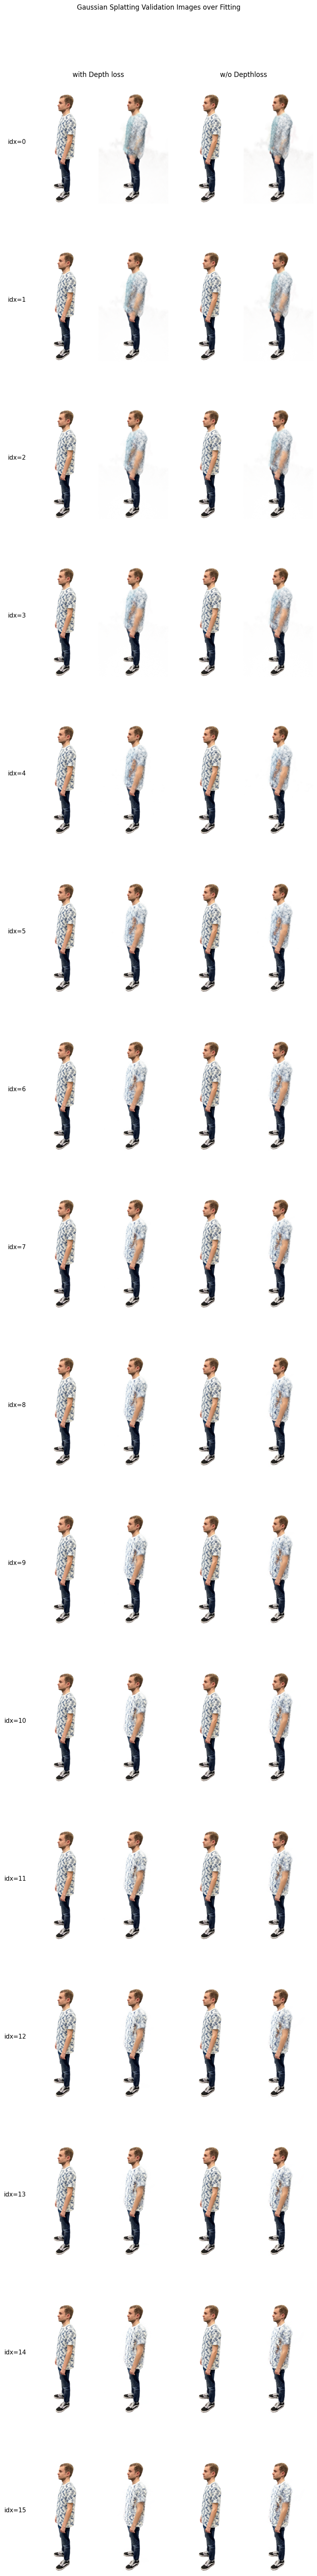

In [24]:
plot_wandb_images_two_runs_by_index(
    depth_runs[2],
    backseg_runs[2],
    metric="gsplat_val/image_3",
    title="Gaussian Splatting Validation Images over Fitting",
    labels=("with Depth loss", "w/o Depth loss"),
)


There is almost no difference visible. That is because the background segmentation already does a good job in preventing artifacts. The depth geometry is also already pretty good because of the 360-degree input images. The depth loss only provides a small additional signal to further refine the geometry, but the visual difference is not huge. In the last iterations, the improvement is visible in the arm on the other side, which is no longer as visible through the body.

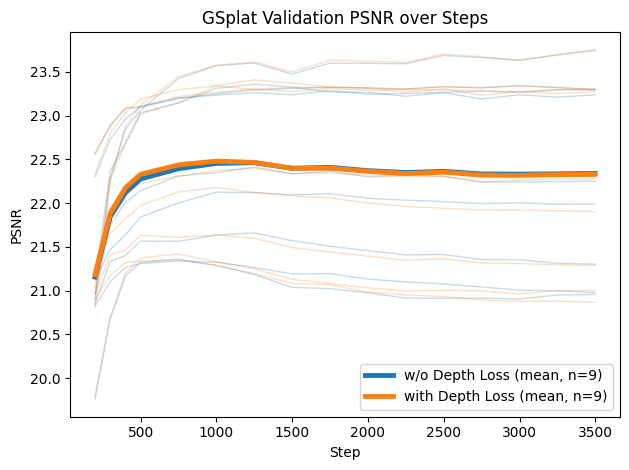

In [22]:
plot_wandb_metric_compare_runs_plus_mean(
    backseg_runs,
    depth_runs,
    metric="gsplat_val/psnr",
    title="GSplat Validation PSNR over Steps",
    xlabel="Step",
    ylabel="PSNR",
    label_a="w/o Depth Loss",
    label_b="with Depth Loss",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)

The PSNR improved just so slightly, that its almost not visible in the plot. The mean PSNR is slightly higher for the depth loss runs, but its such a small differnce, that its not significnat

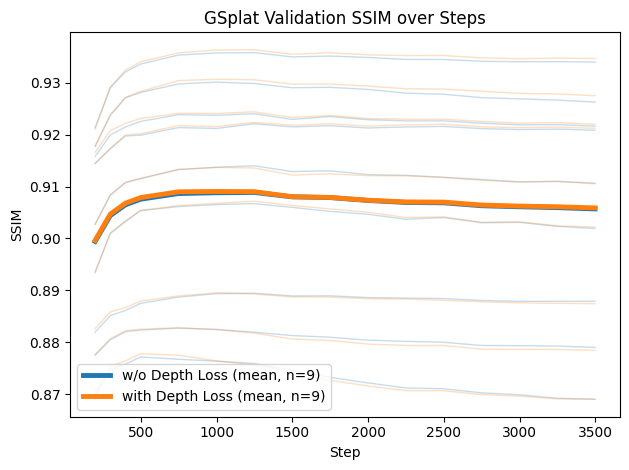

In [25]:
plot_wandb_metric_compare_runs_plus_mean(
    backseg_runs,
    depth_runs,
    metric="gsplat_val/ssim",
    title="GSplat Validation SSIM over Steps",
    xlabel="Step",
    ylabel="SSIM",
    label_a="w/o Depth Loss",
    label_b="with Depth Loss",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)

same for SSIM, the improvement is very small, almost not visible. 

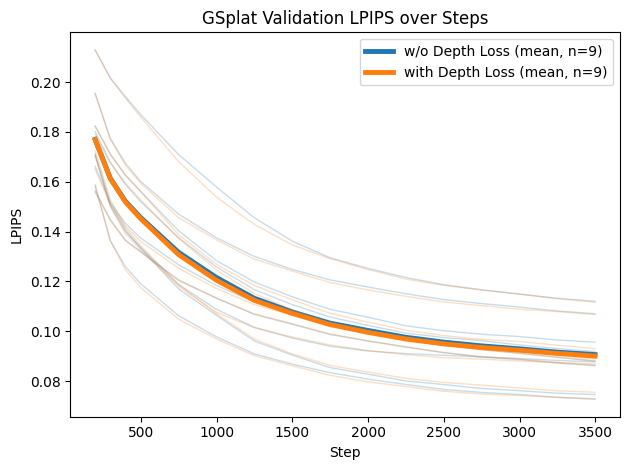

In [26]:
plot_wandb_metric_compare_runs_plus_mean(
    backseg_runs,
    depth_runs,
    metric="gsplat_val/lpips",
    title="GSplat Validation LPIPS over Steps",
    xlabel="Step",
    ylabel="LPIPS",
    label_a="w/o Depth Loss",
    label_b="with Depth Loss",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)

same for LPIPS, the improvement is very small, almost not visible. 

In [49]:


import wandb

api = wandb.Api()
entity = "vton_pipeline"
project = "vton_depthloss"

runs = api.runs(f"{entity}/{project}")

depthlambda_runs = []

for r in runs:
    depthlambda_runs.append(r)

print("depth runs:", len(depthlambda_runs))


depth runs: 41


In [50]:

depthlambda_runs = [depthlambda_runs[i] for i in [1, 4, 3, 10, 8, 6, 9, 5,]]

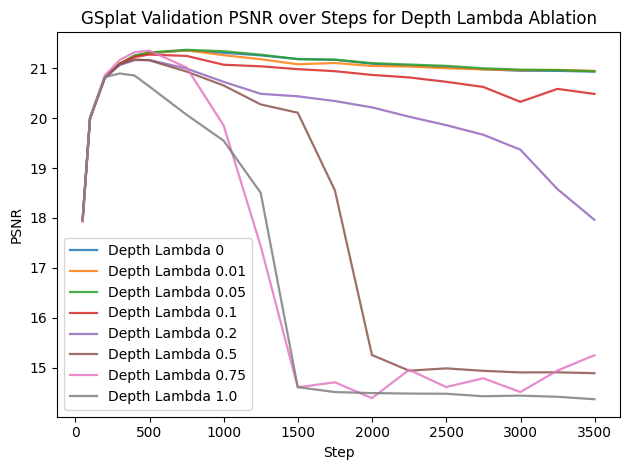

In [52]:
plot_wandb_metric_runs_overlay(
    depthlambda_runs,
    metric="gsplat_val/psnr",
    title="GSplat Validation PSNR over Steps for Depth Lambda Ablation",
    xlabel="Step",
    ylabel="PSNR",
    labels=["Depth Lambda 0", "Depth Lambda 0.01", "Depth Lambda 0.05", "Depth Lambda 0.1", "Depth Lambda 0.2", "Depth Lambda 0.5", "Depth Lambda 0.75", "Depth Lambda 1.0"],
)


here we experiment with different lambdas for the depth regularization loss. Small Lambdas have almsot no effect and bigger lambdas have a strong negativ effect because they over regularize and delete Gaussians too aggressively. This also shows, that 360 degrees images plus backgropund segmentation is already very good. Better gaussian Splatting effect wont come from Gaussian splatting Optimization but from better Qwen Geometry.

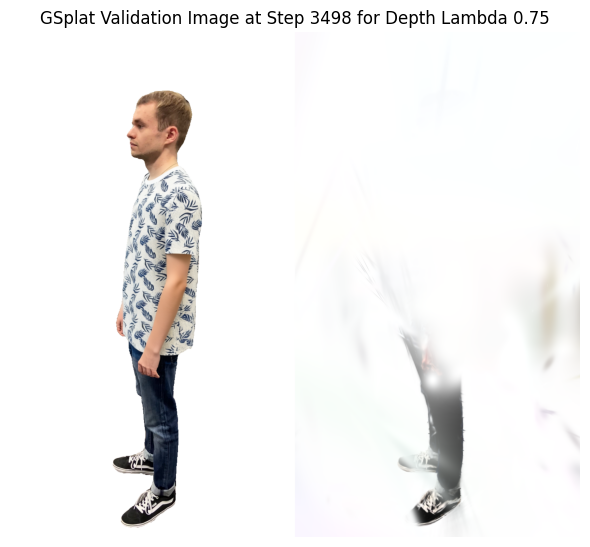

In [62]:
plot_wandb_image_at_step(
    depthlambda_runs[-2],
    metric="gsplat_val/image_3",
    title="GSplat Validation Image at Step 3498 for Depth Lambda 0.75",
    step=3498,
)


here one Example of an overregularized Splatting. Almsot the Whole body got deleted and only a few Gaussians remain.